# Can the 20240812 reference drift be represented by a curl-free field?

This notebook is a deliberately small, empirical gut check of the assumption

\[
v(z) = -\nabla \phi(z), \qquad z\in\mathbb{R}^{10},
\]

for the conditional mean **drift velocity** of the continuously imaged WT reference embryos.
It does not analyze density-weighted probability flux.

The comparison is performed entirely in the native 10D morph-VAE PCA coordinates. The main
safeguard against an overly optimistic answer is embryo-level cross-validation: every reported
prediction is for an embryo excluded from field fitting. We compare two smooth neural fields with
nearly identical parameter counts:

- **Unconstrained field:** directly outputs a 10D velocity.
- **Gradient field:** outputs a scalar potential; velocity is its negative gradient by construction.

Both models use smooth Softplus networks, the same optimizer/regularization, and lightly
Savitzky–Golay-smoothed trajectories. Evaluation is restricted to locally well-supported points.
The comparison asks how much of the predictable drift captured by the unconstrained field is also
captured by the gradient-only field.

Important limitation: these trajectories occupy a lower-dimensional region within the 10D space.
The notebook can diagnose curl only along directions supported by the data, not in empty off-manifold
directions.

In [1]:
from __future__ import annotations

import copy
import os
import random
import time
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy.signal import savgol_filter
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.neighbors import NearestNeighbors
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 20260805
EXPERIMENT_ID = "20240812"
N_DIMS = 10
PCA_COLS = [f"PCA_{i:02}_bio" for i in range(N_DIMS)]
TIME_COL = "predicted_stage_hpf"

# Dense, nearly complete portion of the trajectories.
STAGE_RANGE = (14.0, 44.0)

# Primary smoothing and model settings. Sensitivity to smoothing is checked at the end.
SG_WINDOW = 7
SG_POLYORDER = 2
SMOOTHING_WINDOWS = (5, 7, 11)
CV_FOLDS = 3
SUPPORT_K = 25
SUPPORT_QUANTILE = 0.90

# Widths are slightly different so parameter counts are essentially identical.
FULL_WIDTH = 48
GRAD_WIDTH = 52
MAX_EPOCHS = 200
PATIENCE_EPOCHS = 35
N_RESTARTS = 2
BATCH_SIZE = 512
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4

RUN_SMOOTHING_SENSITIVITY = True
BOOTSTRAP_REPS = 500

HERE = Path.cwd()
if HERE.name != "20260805":
    HERE = Path("/Users/nick/Projects/repositories/morphseq/results/nlammers/20260805")

data_root = Path(os.environ.get(
    "MORPHSEQ_DATA_ROOT", "/Users/nick/Projects/data/morphseq/results/20260528"
))
DATA_PATH = data_root / "ab_ref_pca_morph_df.csv"
FIG_DIR = HERE / "figures" / "drift_curl_free"
FIG_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#e5e5e5",
    "grid.linewidth": 0.6,
    "font.size": 10,
    "savefig.bbox": "tight",
})

torch.set_num_threads(min(8, os.cpu_count() or 1))


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def save_figure(fig: mpl.figure.Figure, stem: str) -> None:
    for suffix in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{stem}.{suffix}", dpi=200)


set_seed(SEED)
print("data:", DATA_PATH)
print("figures:", FIG_DIR)
print("torch:", torch.__version__, "(CPU for reproducibility)")

data: /Users/nick/Projects/data/morphseq/results/20260528/ab_ref_pca_morph_df.csv
figures: /Users/nick/Projects/repositories/morphseq/results/nlammers/20260805/figures/drift_curl_free
torch: 2.0.0 (CPU for reproducibility)


## 1. Load and audit the continuous reference trajectories

`predicted_stage_hpf` is used as the time coordinate. All selected embryos were imaged at the same
temperature (29 °C), so this differs from elapsed acquisition time only by a common positive scale.
Such a scale changes velocity magnitudes but not whether the field is curl-free.

In [2]:
raw = pd.read_csv(DATA_PATH)
experiment = raw["embryo_id"].astype(str).str.split("_").str[0]
ref = raw.loc[experiment.eq(EXPERIMENT_ID)].copy()
ref = ref.sort_values(["embryo_id", TIME_COL]).reset_index(drop=True)

audit = pd.Series({
    "observations": len(ref),
    "embryos": ref["embryo_id"].nunique(),
    "temperature_min": ref["temperature"].min(),
    "temperature_max": ref["temperature"].max(),
    "stage_min": ref[TIME_COL].min(),
    "stage_max": ref[TIME_COL].max(),
    "duplicate_snip_ids": ref["snip_id"].duplicated().sum(),
    "missing_PCA_values": int(ref[PCA_COLS].isna().sum().sum()),
})
display(audit.to_frame("value"))

rows_per_embryo = ref.groupby("embryo_id").size()
print("rows/embryo quantiles:")
display(rows_per_embryo.quantile([0, 0.1, 0.5, 0.9, 1]).to_frame("rows"))

,value
observations,6817.000000
embryos,92.000000
temperature_min,29.000000
temperature_max,29.000000
stage_min,12.000000
stage_max,46.436115
duplicate_snip_ids,0.000000
missing_PCA_values,0.000000


rows/embryo quantiles:


,rows
0.0,61.0
0.1,73.0
0.5,75.0
0.9,75.0
1.0,75.0


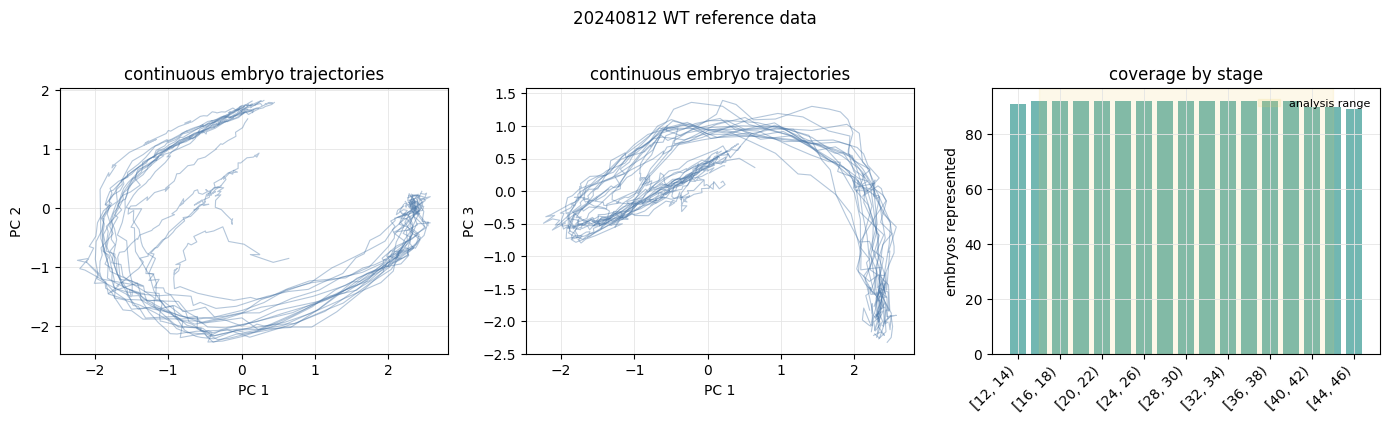

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))
rng = np.random.default_rng(SEED)
embryos_to_show = rng.choice(ref["embryo_id"].unique(), 18, replace=False)
show = ref[ref["embryo_id"].isin(embryos_to_show)]

for ax, (pc_x, pc_y) in zip(axes[:2], [(0, 1), (0, 2)]):
    for _, g in show.groupby("embryo_id"):
        ax.plot(g[PCA_COLS[pc_x]], g[PCA_COLS[pc_y]], color="#4c78a8", alpha=0.42, lw=0.8)
    ax.set_xlabel(f"PC {pc_x + 1}")
    ax.set_ylabel(f"PC {pc_y + 1}")
    ax.set_title("continuous embryo trajectories")

stage_bins = pd.cut(ref[TIME_COL], np.arange(12, 48, 2), right=False)
coverage = ref.assign(stage_bin=stage_bins).groupby("stage_bin", observed=True)["embryo_id"].nunique()
axes[2].bar(np.arange(len(coverage)), coverage.values, color="#72b7b2")
axes[2].set_xticks(np.arange(len(coverage))[::2])
axes[2].set_xticklabels([str(x) for x in coverage.index[::2]], rotation=45, ha="right")
axes[2].axvspan(1, 15, color="#f2cf5b", alpha=0.13, label="analysis range")
axes[2].set_ylabel("embryos represented")
axes[2].set_title("coverage by stage")
axes[2].legend(frameon=False, fontsize=8)
fig.suptitle("20240812 WT reference data", y=1.02)
fig.tight_layout()
save_figure(fig, "01_reference_data_audit")
plt.show()

## 2. Smooth each trajectory and infer velocities

Each embryo is first linearly resampled to its own median frame interval. A quadratic
Savitzky–Golay filter is then applied independently to all ten coordinates, and its analytic
derivative supplies the velocity. Half a filter window is trimmed from either endpoint.

This is intentionally modest smoothing: the primary 7-frame window spans about 3.2 developmental
hours, and 5- and 11-frame windows are checked later. The same smoothing is used for the target
velocities of both field models.

In [4]:
def prepare_velocity_table(
    df: pd.DataFrame,
    window: int,
    polyorder: int = SG_POLYORDER,
    stage_range: tuple[float, float] = STAGE_RANGE,
) -> tuple[pd.DataFrame, dict[str, dict[str, np.ndarray]]]:
    """Resample, smooth, and differentiate every embryo trajectory."""
    if window % 2 != 1:
        raise ValueError("Savitzky–Golay window must be odd")

    records: list[dict[str, float | str]] = []
    curves: dict[str, dict[str, np.ndarray]] = {}
    trim = window // 2

    for embryo_id, g in df.groupby("embryo_id", sort=True):
        g = g.sort_values(TIME_COL)
        t_raw = g[TIME_COL].to_numpy(float)
        z_raw = g[PCA_COLS].to_numpy(float)
        dt = float(np.median(np.diff(t_raw)))
        t = np.arange(t_raw[0], t_raw[-1] + 0.5 * dt, dt)
        z_interp = np.column_stack([
            np.interp(t, t_raw, z_raw[:, j]) for j in range(N_DIMS)
        ])
        if len(t) < window:
            continue

        z_smooth = savgol_filter(
            z_interp, window_length=window, polyorder=polyorder, axis=0, mode="interp"
        )
        velocity = savgol_filter(
            z_interp, window_length=window, polyorder=polyorder,
            deriv=1, delta=dt, axis=0, mode="interp",
        )
        curves[str(embryo_id)] = {
            "time_raw": t_raw,
            "z_raw": z_raw,
            "time": t,
            "z_smooth": z_smooth,
            "velocity": velocity,
        }

        for i in range(trim, len(t) - trim - 1):
            if not (stage_range[0] <= t[i] <= stage_range[1]):
                continue
            rec: dict[str, float | str] = {
                "embryo_id": str(embryo_id),
                "stage_hpf": float(t[i]),
                "dt_hpf": float(t[i + 1] - t[i]),
            }
            rec.update({f"x_{j}": float(z_smooth[i, j]) for j in range(N_DIMS)})
            rec.update({f"v_{j}": float(velocity[i, j]) for j in range(N_DIMS)})
            rec.update({f"next_{j}": float(z_smooth[i + 1, j]) for j in range(N_DIMS)})
            records.append(rec)

    return pd.DataFrame.from_records(records), curves


velocity_df, smoothed_curves = prepare_velocity_table(ref, SG_WINDOW)
X_COLS = [f"x_{j}" for j in range(N_DIMS)]
V_COLS = [f"v_{j}" for j in range(N_DIMS)]
NEXT_COLS = [f"next_{j}" for j in range(N_DIMS)]

print(
    f"velocity observations: {len(velocity_df):,} from "
    f"{velocity_df['embryo_id'].nunique()} embryos"
)
print(
    "stage range: %.2f–%.2f hpf; median dt: %.3f hpf"
    % (
        velocity_df["stage_hpf"].min(),
        velocity_df["stage_hpf"].max(),
        velocity_df["dt_hpf"].median(),
    )
)

velocity observations: 5,984 from 92 embryos
stage range: 14.00–43.99 hpf; median dt: 0.458 hpf


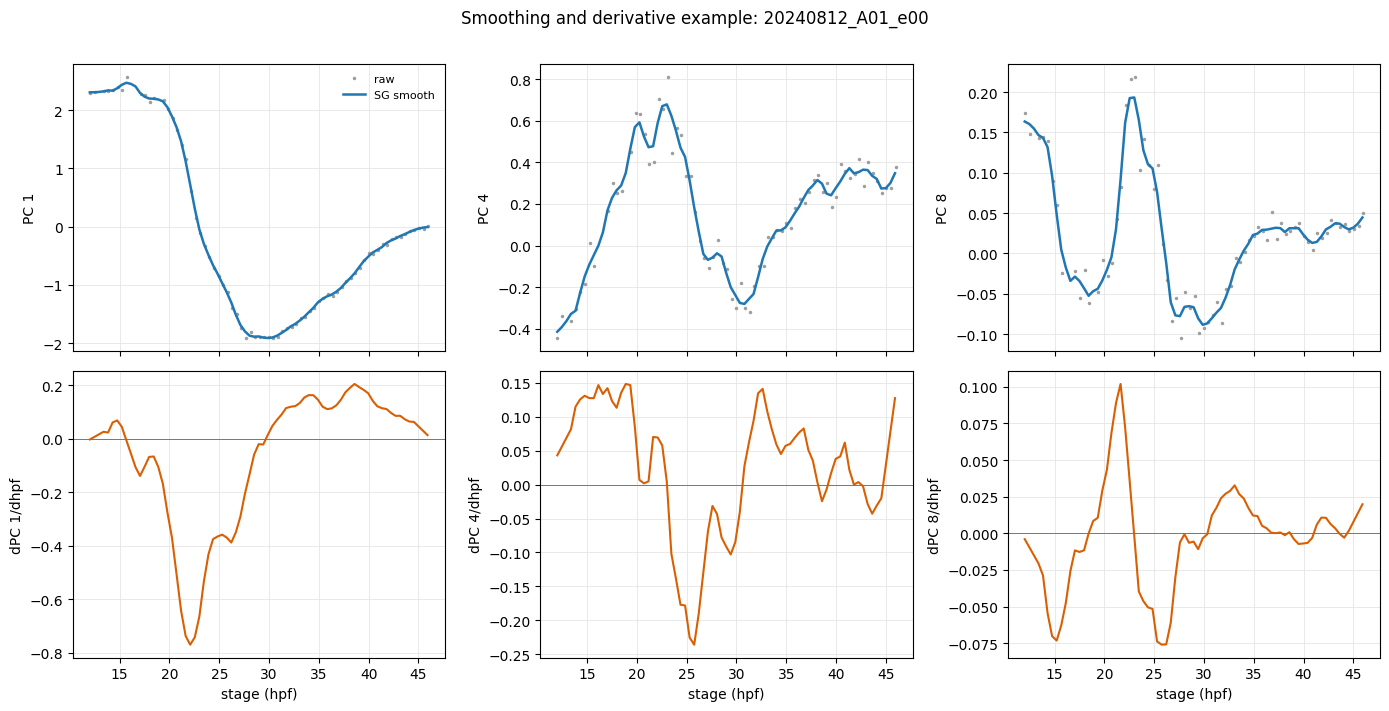

In [5]:
example_id = sorted(smoothed_curves)[0]
example = smoothed_curves[example_id]
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex="col")

for col, pc_idx in enumerate([0, 3, 7]):
    axes[0, col].plot(example["time_raw"], example["z_raw"][:, pc_idx], ".", ms=3,
                      color="#9e9e9e", label="raw")
    axes[0, col].plot(example["time"], example["z_smooth"][:, pc_idx], lw=1.8,
                      color="#1f77b4", label="SG smooth")
    axes[0, col].set_ylabel(f"PC {pc_idx + 1}")
    axes[1, col].plot(example["time"], example["velocity"][:, pc_idx],
                      color="#d95f02", lw=1.5)
    axes[1, col].axhline(0, color="#777777", lw=0.7)
    axes[1, col].set_ylabel(f"dPC {pc_idx + 1}/dhpf")
    axes[1, col].set_xlabel("stage (hpf)")

axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle(f"Smoothing and derivative example: {example_id}", y=1.01)
fig.tight_layout()
save_figure(fig, "02_smoothing_example")
plt.show()

## 3. Check the dimensionality and define “data-rich” support

PCA coordinates are not standardized per axis: anisotropic rescaling would change the geometric
meaning of a gradient and therefore the curl-free question. Models use only translation and one
common scalar scale, which preserve Euclidean angles and curl-freeness.

For evaluation, a test point is considered supported when its mean distance to the 25 nearest
training observations is no larger than the 90th percentile of cross-embryo neighbor distances
within the training set. This threshold is recomputed inside each CV fold.

,participation_dimension,dimensions_for_80pct,dimensions_for_90pct
0.1,3.30,3.0,4.0
0.5,4.01,4.0,5.0
0.9,4.65,4.0,5.0


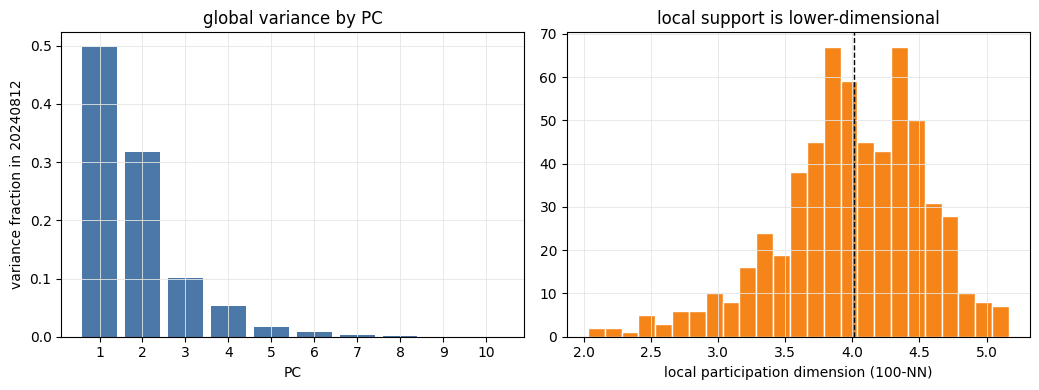

In [6]:
def local_dimension_diagnostics(
    X: np.ndarray, n_centers: int = 600, k: int = 100, seed: int = SEED
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    center_idx = rng.choice(len(X), min(n_centers, len(X)), replace=False)
    nbrs = NearestNeighbors(n_neighbors=min(k + 1, len(X))).fit(X)
    _, neighbor_idx = nbrs.kneighbors(X[center_idx])
    rows = []
    for ids in neighbor_idx[:, 1:]:
        eig = np.linalg.eigvalsh(np.cov(X[ids], rowvar=False))[::-1].clip(0)
        cumulative = np.cumsum(eig) / eig.sum()
        rows.append({
            "participation_dimension": eig.sum() ** 2 / np.sum(eig ** 2),
            "dimensions_for_80pct": int(np.searchsorted(cumulative, 0.80) + 1),
            "dimensions_for_90pct": int(np.searchsorted(cumulative, 0.90) + 1),
        })
    return pd.DataFrame(rows)


X_all = velocity_df[X_COLS].to_numpy(float)
local_dim = local_dimension_diagnostics(X_all)
pc_variance = np.var(X_all, axis=0, ddof=1)

display(local_dim.quantile([0.1, 0.5, 0.9]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
axes[0].bar(np.arange(1, N_DIMS + 1), pc_variance / pc_variance.sum(), color="#4c78a8")
axes[0].set_xlabel("PC")
axes[0].set_ylabel("variance fraction in 20240812")
axes[0].set_xticks(np.arange(1, N_DIMS + 1))
axes[0].set_title("global variance by PC")
axes[1].hist(local_dim["participation_dimension"], bins=25, color="#f58518", edgecolor="white")
axes[1].axvline(local_dim["participation_dimension"].median(), color="black", ls="--", lw=1)
axes[1].set_xlabel("local participation dimension (100-NN)")
axes[1].set_title("local support is lower-dimensional")
fig.tight_layout()
save_figure(fig, "03_support_dimensionality")
plt.show()

## 4. Two parameter-matched smooth drift models

The unconstrained network has 48 hidden units; the potential network has 52. This makes their
trainable parameter counts almost exactly equal while preserving the same depth and smooth
activation. The potential model's velocity is obtained with automatic differentiation, so its
Jacobian is symmetric (and curl is zero) by construction.

Within each outer CV fold, 15% of the training embryos are used for early stopping. No frames from
an evaluation embryo enter fitting, normalization, or early stopping.

In [7]:
class SmoothMLP(nn.Module):
    def __init__(self, output_dim: int, width: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_DIMS, width),
            nn.Softplus(),
            nn.Linear(width, width),
            nn.Softplus(),
            nn.Linear(width, output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DriftField(nn.Module):
    def __init__(self, kind: str):
        super().__init__()
        if kind not in {"unconstrained", "gradient"}:
            raise ValueError(kind)
        self.kind = kind
        width = FULL_WIDTH if kind == "unconstrained" else GRAD_WIDTH
        self.net = SmoothMLP(N_DIMS if kind == "unconstrained" else 1, width)

    def velocity(self, x: torch.Tensor, *, create_graph: bool = False) -> torch.Tensor:
        if self.kind == "unconstrained":
            return self.net(x)
        x = x.requires_grad_(True)
        phi = self.net(x)
        return -torch.autograd.grad(phi.sum(), x, create_graph=create_graph)[0]


def parameter_count(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


for kind in ("unconstrained", "gradient"):
    print(kind, f"{parameter_count(DriftField(kind)):,} parameters")

unconstrained 3,370 parameters
gradient 3,381 parameters


In [8]:
def predict_velocity(model: DriftField, X_scaled: np.ndarray, batch_size: int = 2048) -> np.ndarray:
    model.eval()
    predictions = []
    for start in range(0, len(X_scaled), batch_size):
        xb = torch.as_tensor(X_scaled[start:start + batch_size], dtype=torch.float32)
        if model.kind == "unconstrained":
            with torch.no_grad():
                pred = model.velocity(xb)
        else:
            with torch.enable_grad():
                pred = model.velocity(xb, create_graph=False)
        predictions.append(pred.detach().cpu().numpy())
    return np.vstack(predictions)


def _fit_field_once(
    kind: str,
    X_train: np.ndarray,
    V_train: np.ndarray,
    X_val: np.ndarray,
    V_val: np.ndarray,
    seed: int,
    verbose: bool = False,
) -> tuple[DriftField, dict[str, np.ndarray | float], pd.DataFrame]:
    """Fit one field with isotropic scaling and embryo-held-out early stopping."""
    set_seed(seed)
    x_mean = X_train.mean(axis=0)
    x_scale = float(np.sqrt(np.mean((X_train - x_mean) ** 2)))
    v_scale = float(np.sqrt(np.mean(V_train ** 2)))
    x_scale = max(x_scale, 1e-8)
    v_scale = max(v_scale, 1e-8)

    Xtr = ((X_train - x_mean) / x_scale).astype("float32")
    Vtr = (V_train / v_scale).astype("float32")
    Xva = ((X_val - x_mean) / x_scale).astype("float32")
    Vva = (V_val / v_scale).astype("float32")

    model = DriftField(kind)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    robust_loss = nn.SmoothL1Loss(beta=0.5)
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(Vtr)),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )

    best_loss = np.inf
    best_epoch = 0
    best_state = None
    history = []

    for epoch in range(MAX_EPOCHS + 1):
        model.train()
        train_loss = 0.0
        n_seen = 0
        for xb, vb in loader:
            optimizer.zero_grad(set_to_none=True)
            pred = model.velocity(xb, create_graph=(kind == "gradient"))
            loss = robust_loss(pred, vb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            optimizer.step()
            train_loss += float(loss.detach()) * len(xb)
            n_seen += len(xb)

        if epoch % 5 == 0:
            val_pred = predict_velocity(model, Xva)
            val_mse = float(np.mean((val_pred - Vva) ** 2))
            history.append({
                "epoch": epoch,
                "train_huber": train_loss / n_seen,
                "val_mse": val_mse,
            })
            if val_mse < best_loss - 1e-5:
                best_loss = val_mse
                best_epoch = epoch
                best_state = {
                    key: value.detach().cpu().clone()
                    for key, value in model.state_dict().items()
                }
            if epoch - best_epoch >= PATIENCE_EPOCHS:
                break

    if best_state is None:
        raise RuntimeError("No model checkpoint was recorded")
    model.load_state_dict(best_state)
    if verbose:
        print(f"{kind:13s}: best epoch {best_epoch:3d}, normalized val MSE {best_loss:.4f}")
    scaler = {"x_mean": x_mean, "x_scale": x_scale, "v_scale": v_scale}
    return model, scaler, pd.DataFrame(history)


def fit_field(
    kind: str,
    X_train: np.ndarray,
    V_train: np.ndarray,
    X_val: np.ndarray,
    V_val: np.ndarray,
    seed: int,
    verbose: bool = False,
) -> tuple[DriftField, dict[str, np.ndarray | float], pd.DataFrame]:
    """Use validation embryos to select among a small number of random restarts."""
    candidates = []
    for restart in range(N_RESTARTS):
        model, scaler, history = _fit_field_once(
            kind, X_train, V_train, X_val, V_val,
            seed=seed + 10_000 * restart,
            verbose=False,
        )
        candidates.append((history["val_mse"].min(), restart, model, scaler, history))
    _, restart, model, scaler, history = min(candidates, key=lambda item: item[0])
    if verbose:
        best = history.loc[history["val_mse"].idxmin()]
        print(
            f"{kind:13s}: restart {restart}, best epoch {int(best['epoch']):3d}, "
            f"normalized val MSE {best['val_mse']:.4f}"
        )
    return model, scaler, history

In [9]:
def cross_embryo_knn_distance(
    X: np.ndarray, groups: np.ndarray, k: int = SUPPORT_K
) -> np.ndarray:
    """Mean distance to k neighbors from other embryos only."""
    n_candidates = min(len(X), max(250, 8 * k + 1))
    distances, indices = NearestNeighbors(n_neighbors=n_candidates).fit(X).kneighbors(X)
    out = np.full(len(X), np.nan)
    for i in range(len(X)):
        keep = groups[indices[i]] != groups[i]
        selected = distances[i, keep][:k]
        if len(selected) == k:
            out[i] = selected.mean()
    return out


def query_knn_distance(X_query: np.ndarray, X_train: np.ndarray, k: int = SUPPORT_K) -> np.ndarray:
    distances, _ = NearestNeighbors(n_neighbors=min(k, len(X_train))).fit(X_train).kneighbors(X_query)
    return distances.mean(axis=1)


def field_jacobian(
    model: DriftField,
    X_scaled: np.ndarray,
    scale_factor: float,
    batch_size: int = 1024,
) -> np.ndarray:
    """Evaluate dv/dx using batched autograd; scale_factor converts back to native units."""
    model.eval()
    jacobians = []
    for start in range(0, len(X_scaled), batch_size):
        xb = torch.as_tensor(
            X_scaled[start:start + batch_size], dtype=torch.float32
        ).requires_grad_(True)
        velocity = model.velocity(xb, create_graph=(model.kind == "gradient"))
        rows = []
        for component in range(N_DIMS):
            grad = torch.autograd.grad(
                velocity[:, component].sum(),
                xb,
                retain_graph=(component < N_DIMS - 1),
                create_graph=False,
            )[0]
            rows.append(grad.detach().cpu().numpy())
        jacobians.append(np.stack(rows, axis=1) * scale_factor)
    return np.concatenate(jacobians, axis=0)


def cosine_similarity_rows(observed: np.ndarray, predicted: np.ndarray) -> np.ndarray:
    denom = np.linalg.norm(observed, axis=1) * np.linalg.norm(predicted, axis=1)
    return np.divide(
        np.sum(observed * predicted, axis=1),
        denom,
        out=np.full(len(observed), np.nan),
        where=denom > 1e-12,
    )

## 5. Embryo-held-out comparison in dense regions

Primary metrics:

- **Velocity \(R^2\):** improvement over the training-fold mean drift.
- **One-step skill:** improvement in next-position error over persistence (predicting no motion).
- **Predictable drift captured:** gradient-field improvement divided by unconstrained-field
  improvement. A value of 1 means the gradient field captures everything the full field predicts;
  0.8 means it captures 80% of that predictable structure.
- **Angular agreement:** cosine between observed and predicted 10D velocities.

In [10]:
def run_group_cv(
    table: pd.DataFrame,
    n_splits: int = CV_FOLDS,
    seed: int = SEED,
    verbose: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    X = table[X_COLS].to_numpy(float)
    V = table[V_COLS].to_numpy(float)
    X_next = table[NEXT_COLS].to_numpy(float)
    dt = table["dt_hpf"].to_numpy(float)
    groups = table["embryo_id"].to_numpy(str)
    stages = table["stage_hpf"].to_numpy(float)

    prediction_frames = []
    fold_rows = []
    outer = GroupKFold(n_splits=n_splits)

    for fold, (outer_train, test) in enumerate(outer.split(X, groups=groups)):
        inner = GroupShuffleSplit(
            n_splits=1, test_size=0.15, random_state=seed + fold
        )
        inner_fit, inner_val = next(
            inner.split(X[outer_train], groups=groups[outer_train])
        )
        fit = outer_train[inner_fit]
        val = outer_train[inner_val]

        # Fold-specific isotropic coordinates for density calculations.
        support_mean = X[fit].mean(axis=0)
        support_scale = float(np.sqrt(np.mean((X[fit] - support_mean) ** 2)))
        X_fit_support = (X[fit] - support_mean) / support_scale
        X_test_support = (X[test] - support_mean) / support_scale
        train_cross_dist = cross_embryo_knn_distance(
            X_fit_support, groups[fit], k=SUPPORT_K
        )
        support_cutoff = float(np.nanquantile(train_cross_dist, SUPPORT_QUANTILE))
        test_dist = query_knn_distance(X_test_support, X_fit_support, k=SUPPORT_K)
        dense = test_dist <= support_cutoff

        if verbose:
            print(
                f"fold {fold + 1}/{n_splits}: fit={len(fit):,}, val={len(val):,}, "
                f"test={len(test):,}; dense test={dense.mean():.1%}"
            )

        fold_pred = pd.DataFrame({
            "row_id": test,
            "fold": fold,
            "embryo_id": groups[test],
            "stage_hpf": stages[test],
            "dt_hpf": dt[test],
            "support_distance": test_dist,
            "support_cutoff": support_cutoff,
            "dense": dense,
        })
        for j in range(N_DIMS):
            fold_pred[f"x_{j}"] = X[test, j]
            fold_pred[f"v_{j}"] = V[test, j]
            fold_pred[f"next_{j}"] = X_next[test, j]

        baseline = V[fit].mean(axis=0)
        for j in range(N_DIMS):
            fold_pred[f"baseline_{j}"] = baseline[j]

        fitted = {}
        for model_index, kind in enumerate(("unconstrained", "gradient")):
            start = time.time()
            model, scaler, history = fit_field(
                kind,
                X[fit], V[fit], X[val], V[val],
                seed=seed + 100 * fold + model_index,
                verbose=verbose,
            )
            X_test_scaled = (X[test] - scaler["x_mean"]) / scaler["x_scale"]
            pred = predict_velocity(model, X_test_scaled) * scaler["v_scale"]
            for j in range(N_DIMS):
                fold_pred[f"{kind}_{j}"] = pred[:, j]
            fitted[kind] = (model, scaler, X_test_scaled)

            mask = dense
            mse = float(np.mean((pred[mask] - V[test][mask]) ** 2))
            baseline_mse = float(np.mean((V[test][mask] - baseline) ** 2))
            fold_rows.append({
                "fold": fold,
                "model": kind,
                "n_dense": int(mask.sum()),
                "dense_fraction": float(mask.mean()),
                "velocity_mse": mse,
                "velocity_r2": 1 - mse / baseline_mse,
                "median_cosine": float(np.nanmedian(cosine_similarity_rows(V[test][mask], pred[mask]))),
                "runtime_seconds": time.time() - start,
                "best_epoch": int(history.loc[history["val_mse"].idxmin(), "epoch"]),
            })

        # Local curl diagnostic for the learned unconstrained field. First form
        # the ambient 10D Jacobian, then restrict it to the locally supported
        # tangent space estimated from training neighbors.
        full_model, full_scaler, X_test_scaled = fitted["unconstrained"]
        jac = field_jacobian(
            full_model,
            X_test_scaled,
            scale_factor=float(full_scaler["v_scale"] / full_scaler["x_scale"]),
        )
        symmetric = 0.5 * (jac + np.swapaxes(jac, 1, 2))
        antisymmetric = 0.5 * (jac - np.swapaxes(jac, 1, 2))
        sym_sq = np.sum(symmetric ** 2, axis=(1, 2))
        anti_sq = np.sum(antisymmetric ** 2, axis=(1, 2))
        fold_pred["ambient_curl_fraction"] = anti_sq / np.maximum(sym_sq + anti_sq, 1e-12)

        tangent_neighbor_idx = NearestNeighbors(
            n_neighbors=min(100, len(X_fit_support))
        ).fit(X_fit_support).kneighbors(X_test_support, return_distance=False)
        tangent_dims = np.empty(len(test), dtype=int)
        tangent_curl_fraction = np.empty(len(test), dtype=float)
        tangent_curl_norm = np.empty(len(test), dtype=float)
        tangent_jacobian_norm = np.empty(len(test), dtype=float)
        for i, neighbor_idx in enumerate(tangent_neighbor_idx):
            local = X_fit_support[neighbor_idx]
            eigval, eigvec = np.linalg.eigh(np.cov(local, rowvar=False))
            order = np.argsort(eigval)[::-1]
            eigval = np.clip(eigval[order], 0, None)
            eigvec = eigvec[:, order]
            cumulative = np.cumsum(eigval) / eigval.sum()
            tangent_dim = int(np.searchsorted(cumulative, 0.90) + 1)
            tangent_dim = int(np.clip(tangent_dim, 2, N_DIMS))
            basis = eigvec[:, :tangent_dim]
            tangent_jac = basis.T @ jac[i] @ basis
            tangent_sym = 0.5 * (tangent_jac + tangent_jac.T)
            tangent_anti = 0.5 * (tangent_jac - tangent_jac.T)
            tangent_sym_sq = float(np.sum(tangent_sym ** 2))
            tangent_anti_sq = float(np.sum(tangent_anti ** 2))
            tangent_dims[i] = tangent_dim
            tangent_curl_fraction[i] = tangent_anti_sq / max(
                tangent_sym_sq + tangent_anti_sq, 1e-12
            )
            tangent_curl_norm[i] = np.sqrt(tangent_anti_sq)
            tangent_jacobian_norm[i] = np.sqrt(tangent_sym_sq + tangent_anti_sq)

        fold_pred["tangent_dim"] = tangent_dims
        fold_pred["curl_fraction"] = tangent_curl_fraction
        fold_pred["curl_norm"] = tangent_curl_norm
        fold_pred["jacobian_norm"] = tangent_jacobian_norm

        # Numerical sanity check: the gradient model's antisymmetric Jacobian should be ~0.
        grad_model, grad_scaler, X_grad_scaled = fitted["gradient"]
        check_n = min(64, len(test))
        grad_jac = field_jacobian(
            grad_model,
            X_grad_scaled[:check_n],
            scale_factor=float(grad_scaler["v_scale"] / grad_scaler["x_scale"]),
        )
        grad_anti = 0.5 * (grad_jac - np.swapaxes(grad_jac, 1, 2))
        fold_pred["gradient_curl_check_max"] = float(np.max(np.abs(grad_anti)))

        prediction_frames.append(fold_pred)

    predictions = pd.concat(prediction_frames, ignore_index=True)
    fold_metrics = pd.DataFrame(fold_rows)
    return predictions, fold_metrics


primary_predictions, primary_fold_metrics = run_group_cv(velocity_df)
display(primary_fold_metrics.round(4))
print(
    "maximum numerical antisymmetric derivative in gradient model:",
    f"{primary_predictions['gradient_curl_check_max'].max():.2e}",
)

fold 1/3: fit=3,321, val=652, test=2,011; dense test=84.5%
unconstrained: restart 0, best epoch 195, normalized val MSE 0.2044
gradient     : restart 0, best epoch 200, normalized val MSE 0.2972
fold 2/3: fit=3,370, val=653, test=1,961; dense test=94.6%
unconstrained: restart 0, best epoch 175, normalized val MSE 0.1951
gradient     : restart 1, best epoch 110, normalized val MSE 0.2238
fold 3/3: fit=3,319, val=653, test=2,012; dense test=90.0%
unconstrained: restart 1, best epoch 185, normalized val MSE 0.1978
gradient     : restart 1, best epoch  45, normalized val MSE 0.4192


,fold,model,n_dense,dense_fraction,velocity_mse,velocity_r2,median_cosine,runtime_seconds,best_epoch
0,0,unconstrained,1699,0.8449,0.0039,0.7944,0.9590,6.0135,195
1,0,gradient,1699,0.8449,0.0044,0.7726,0.9553,8.4048,200
2,1,unconstrained,1855,0.9459,0.0038,0.8036,0.9511,7.0150,175
3,1,gradient,1855,0.9459,0.0048,0.7521,0.9466,7.3009,110
4,2,unconstrained,1811,0.9001,0.0035,0.8240,0.9559,6.7008,185
5,2,gradient,1811,0.9001,0.0053,0.7308,0.9437,3.4281,45


maximum numerical antisymmetric derivative in gradient model: 7.45e-08


In [11]:
def score_predictions(predictions: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, float]]:
    p = predictions.loc[predictions["dense"]].copy()
    observed = p[V_COLS].to_numpy(float)
    current = p[X_COLS].to_numpy(float)
    nxt = p[NEXT_COLS].to_numpy(float)
    dt = p["dt_hpf"].to_numpy(float)[:, None]
    baseline = p[[f"baseline_{j}" for j in range(N_DIMS)]].to_numpy(float)

    sse_zero = float(np.sum((observed - baseline) ** 2))
    persistence_sse = float(np.sum((nxt - current) ** 2))
    rows = []
    errors = {}
    for kind in ("unconstrained", "gradient"):
        predicted = p[[f"{kind}_{j}" for j in range(N_DIMS)]].to_numpy(float)
        sse = float(np.sum((observed - predicted) ** 2))
        next_sse = float(np.sum((nxt - (current + dt * predicted)) ** 2))
        errors[kind] = sse
        rows.append({
            "model": kind,
            "n_points": len(p),
            "n_embryos": p["embryo_id"].nunique(),
            "velocity_rmse": np.sqrt(sse / observed.size),
            "velocity_r2": 1 - sse / sse_zero,
            "median_cosine": np.nanmedian(cosine_similarity_rows(observed, predicted)),
            "one_step_skill_vs_persistence": 1 - next_sse / persistence_sse,
        })

    full_improvement = sse_zero - errors["unconstrained"]
    grad_improvement = sse_zero - errors["gradient"]
    extras = {
        "predictable_drift_captured": grad_improvement / full_improvement,
        "gradient_excess_sse_vs_full": (
            errors["gradient"] - errors["unconstrained"]
        ) / sse_zero,
        "dense_fraction": float(predictions["dense"].mean()),
        "median_tangent_dim": float(p["tangent_dim"].median()),
        "median_full_curl_fraction": float(p["curl_fraction"].median()),
    }
    return pd.DataFrame(rows), extras


primary_summary, primary_extras = score_predictions(primary_predictions)
display(primary_summary.round(4))
display(pd.Series(primary_extras, name="value").to_frame().round(4))

,model,n_points,n_embryos,velocity_rmse,velocity_r2,median_cosine,one_step_skill_vs_persistence
0,unconstrained,5365,92,0.0613,0.8077,0.9553,0.6945
1,gradient,5365,92,0.0697,0.7511,0.9488,0.6494


,value
predictable_drift_captured,0.9299
gradient_excess_sse_vs_full,0.0566
dense_fraction,0.8966
median_tangent_dim,4.0000
median_full_curl_fraction,0.5975


In [12]:
def bootstrap_metrics(
    predictions: pd.DataFrame,
    n_boot: int = BOOTSTRAP_REPS,
    seed: int = SEED,
) -> pd.DataFrame:
    """Embryo-level bootstrap confidence intervals for the aggregate scores."""
    rng = np.random.default_rng(seed)
    embryos = predictions["embryo_id"].unique()
    by_embryo = {e: predictions[predictions["embryo_id"].eq(e)] for e in embryos}
    rows = []
    for b in range(n_boot):
        sampled = rng.choice(embryos, size=len(embryos), replace=True)
        boot = pd.concat([by_embryo[e] for e in sampled], ignore_index=True)
        summary, extras = score_predictions(boot)
        row = {"bootstrap": b, **extras}
        for _, metric_row in summary.iterrows():
            model = metric_row["model"]
            for metric in ("velocity_r2", "median_cosine", "one_step_skill_vs_persistence"):
                row[f"{model}_{metric}"] = metric_row[metric]
        rows.append(row)
    return pd.DataFrame(rows)


primary_bootstrap = bootstrap_metrics(primary_predictions)
ci = primary_bootstrap.quantile([0.025, 0.5, 0.975]).T
ci.columns = ["2.5%", "median", "97.5%"]
display(ci.round(4))

,2.5%,median,97.5%
bootstrap,12.4750,249.5000,486.5250
predictable_drift_captured,0.9136,0.9292,0.9444
gradient_excess_sse_vs_full,0.0453,0.0573,0.0691
dense_fraction,0.8504,0.8961,0.9382
median_tangent_dim,4.0000,4.0000,4.0000
median_full_curl_fraction,0.5862,0.5975,0.6098
unconstrained_velocity_r2,0.7906,0.8084,0.8234
unconstrained_median_cosine,0.9514,0.9554,0.9589
unconstrained_one_step_skill_vs_persistence,0.6752,0.6950,0.7116
gradient_velocity_r2,0.7297,0.7511,0.7704


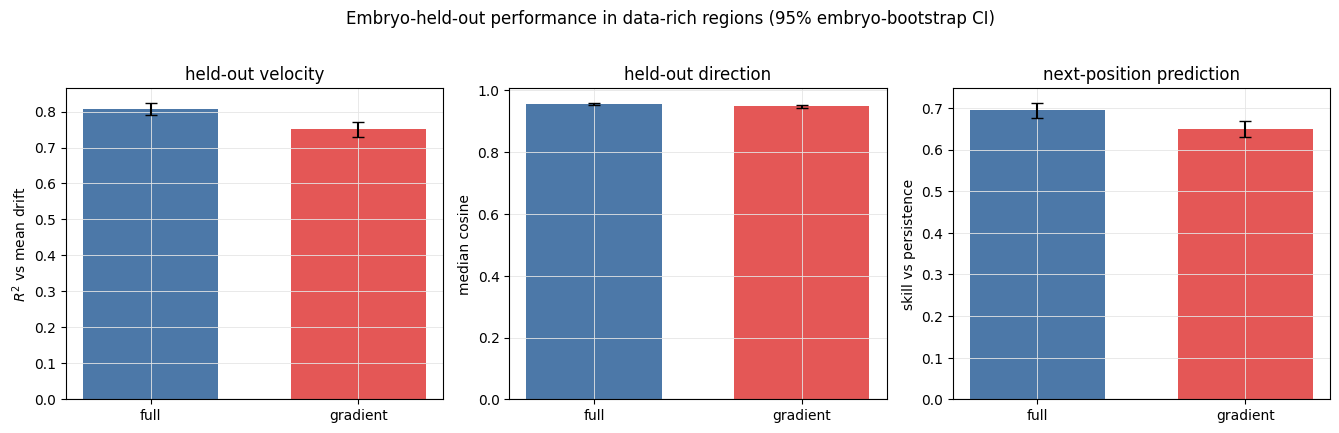

Gradient field captured 93.0% of the drift improvement achieved by the unconstrained field (95% embryo-bootstrap CI 91.4–94.4%).


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
colors = {"unconstrained": "#4c78a8", "gradient": "#e45756"}

for ax, metric, title, ylabel in [
    (axes[0], "velocity_r2", "held-out velocity", "$R^2$ vs mean drift"),
    (axes[1], "median_cosine", "held-out direction", "median cosine"),
    (axes[2], "one_step_skill_vs_persistence", "next-position prediction", "skill vs persistence"),
]:
    for x, kind in enumerate(("unconstrained", "gradient")):
        value = float(primary_summary.loc[primary_summary["model"].eq(kind), metric].iloc[0])
        boots = primary_bootstrap[f"{kind}_{metric}"]
        lo, hi = np.quantile(boots, [0.025, 0.975])
        ax.bar(x, value, color=colors[kind], width=0.65)
        ax.errorbar(x, value, yerr=[[value - lo], [hi - value]], fmt="none", color="black", capsize=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["full", "gradient"])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(0, color="#777777", lw=0.8)

fig.suptitle("Embryo-held-out performance in data-rich regions (95% embryo-bootstrap CI)", y=1.02)
fig.tight_layout()
save_figure(fig, "04_primary_cross_validated_performance")
plt.show()

capture = primary_extras["predictable_drift_captured"]
capture_ci = np.quantile(primary_bootstrap["predictable_drift_captured"], [0.025, 0.975])
print(
    "Gradient field captured %.1f%% of the drift improvement achieved by the unconstrained field "
    "(95%% embryo-bootstrap CI %.1f–%.1f%%)."
    % (100 * capture, 100 * capture_ci[0], 100 * capture_ci[1])
)

## 6. Where does the gradient restriction lose information?

The following plots remain diagnostics rather than a formal Helmholtz decomposition. The residual
between separately fitted models is not automatically a pure rotational component. The local
antisymmetric Jacobian of the unconstrained model is a more direct local curl diagnostic. At each
point, let \(Q\) span the 90%-variance local tangent space estimated from training neighbors. We use
the tangent-restricted Jacobian \(J_T=Q^T J Q\):

\[
A_T(z)=\tfrac12[J_T(z)-J_T(z)^T], \qquad
q_{\mathrm{curl}}=\frac{\|A_T\|_F^2}{\|A_T\|_F^2+\|\tfrac12(J_T+J_T^T)\|_F^2}.
\]

This derivative-based score is evaluated only on held-out embryo positions. It measures local
rotational derivatives in data-supported tangent directions; it is not the fraction of total
velocity energy belonging to a global solenoidal field. The ambient 10D value is retained in the
prediction table for diagnosis but is not used in the conclusion.

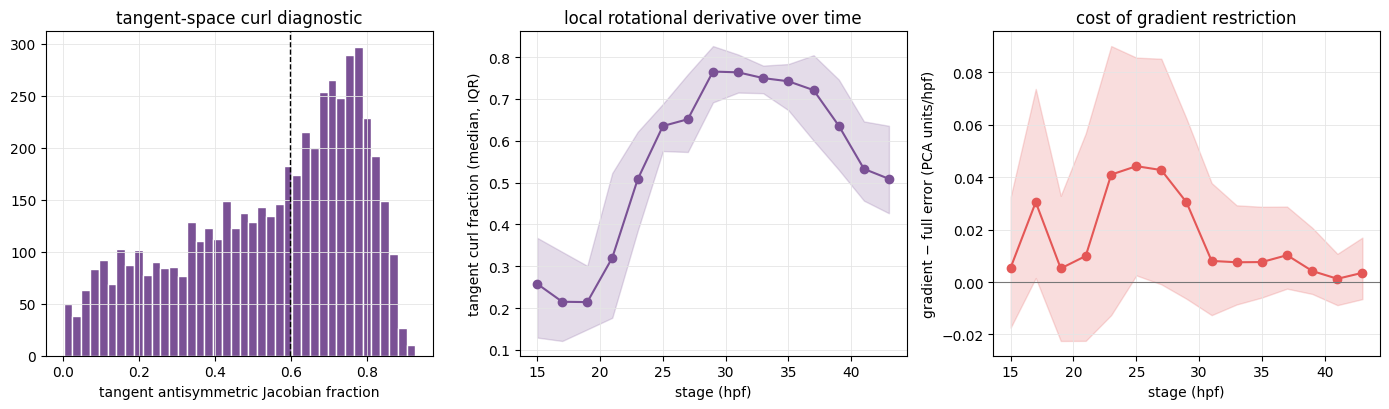

In [14]:
dense_pred = primary_predictions[primary_predictions["dense"]].copy()
observed = dense_pred[V_COLS].to_numpy(float)
full_pred = dense_pred[[f"unconstrained_{j}" for j in range(N_DIMS)]].to_numpy(float)
grad_pred = dense_pred[[f"gradient_{j}" for j in range(N_DIMS)]].to_numpy(float)

dense_pred["full_error"] = np.linalg.norm(observed - full_pred, axis=1)
dense_pred["gradient_error"] = np.linalg.norm(observed - grad_pred, axis=1)
dense_pred["gradient_excess_error"] = dense_pred["gradient_error"] - dense_pred["full_error"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].hist(dense_pred["curl_fraction"], bins=40, color="#7a5195", edgecolor="white")
axes[0].axvline(dense_pred["curl_fraction"].median(), color="black", ls="--", lw=1)
axes[0].set_xlabel("tangent antisymmetric Jacobian fraction")
axes[0].set_title("tangent-space curl diagnostic")

stage_summary = dense_pred.assign(
    stage_bin=pd.cut(dense_pred["stage_hpf"], np.arange(14, 46, 2), right=False)
).groupby("stage_bin", observed=True).agg(
    stage=("stage_hpf", "mean"),
    curl_median=("curl_fraction", "median"),
    curl_q25=("curl_fraction", lambda x: x.quantile(0.25)),
    curl_q75=("curl_fraction", lambda x: x.quantile(0.75)),
    excess_median=("gradient_excess_error", "median"),
    excess_q25=("gradient_excess_error", lambda x: x.quantile(0.25)),
    excess_q75=("gradient_excess_error", lambda x: x.quantile(0.75)),
).reset_index(drop=True)

axes[1].plot(stage_summary["stage"], stage_summary["curl_median"], "o-", color="#7a5195")
axes[1].fill_between(stage_summary["stage"], stage_summary["curl_q25"], stage_summary["curl_q75"],
                     color="#7a5195", alpha=0.2)
axes[1].set_xlabel("stage (hpf)")
axes[1].set_ylabel("tangent curl fraction (median, IQR)")
axes[1].set_title("local rotational derivative over time")

axes[2].plot(stage_summary["stage"], stage_summary["excess_median"], "o-", color="#e45756")
axes[2].fill_between(stage_summary["stage"], stage_summary["excess_q25"], stage_summary["excess_q75"],
                     color="#e45756", alpha=0.2)
axes[2].axhline(0, color="#777777", lw=0.8)
axes[2].set_xlabel("stage (hpf)")
axes[2].set_ylabel("gradient − full error (PCA units/hpf)")
axes[2].set_title("cost of gradient restriction")
fig.tight_layout()
save_figure(fig, "05_curl_and_error_over_stage")
plt.show()

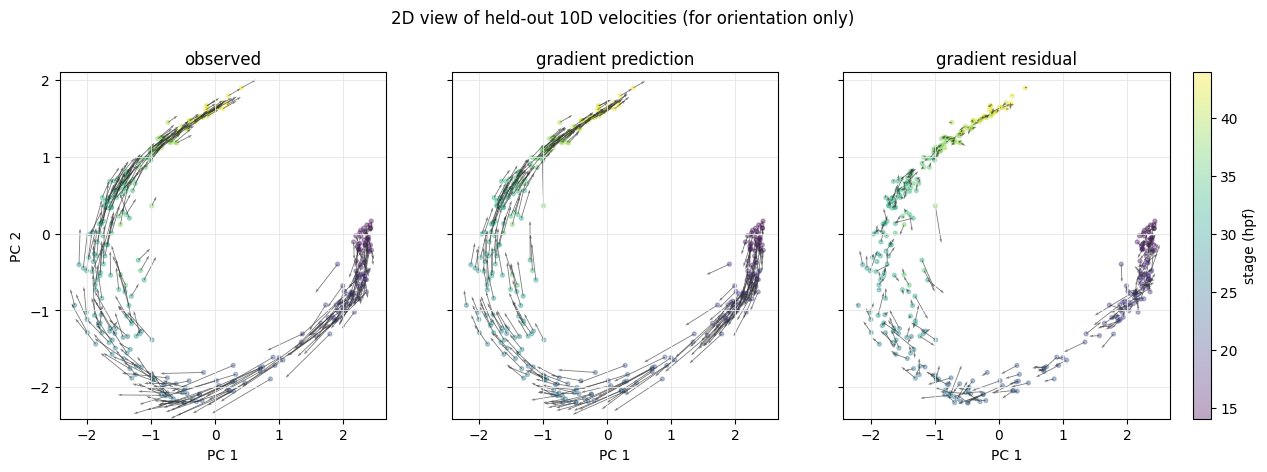

In [15]:
# Low-dimensional views are illustrative only; predictions and errors are still 10D.
rng = np.random.default_rng(SEED)
plot_idx = rng.choice(len(dense_pred), min(350, len(dense_pred)), replace=False)
plot_df = dense_pred.iloc[plot_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
fields = [
    ("observed", observed[plot_idx]),
    ("gradient prediction", grad_pred[plot_idx]),
    ("gradient residual", observed[plot_idx] - grad_pred[plot_idx]),
]
for ax, (title, vectors) in zip(axes, fields):
    sc = ax.scatter(plot_df["x_0"], plot_df["x_1"], c=plot_df["stage_hpf"],
                    cmap="viridis", s=8, alpha=0.35)
    ax.quiver(
        plot_df["x_0"], plot_df["x_1"], vectors[:, 0], vectors[:, 1],
        angles="xy", scale_units="xy", scale=0.8, width=0.0025, color="#333333", alpha=0.65,
    )
    ax.set_xlabel("PC 1")
    ax.set_title(title)
axes[0].set_ylabel("PC 2")
fig.colorbar(sc, ax=axes, fraction=0.025, pad=0.02, label="stage (hpf)")
fig.suptitle("2D view of held-out 10D velocities (for orientation only)", y=1.02)
save_figure(fig, "06_heldout_field_projection")
plt.show()

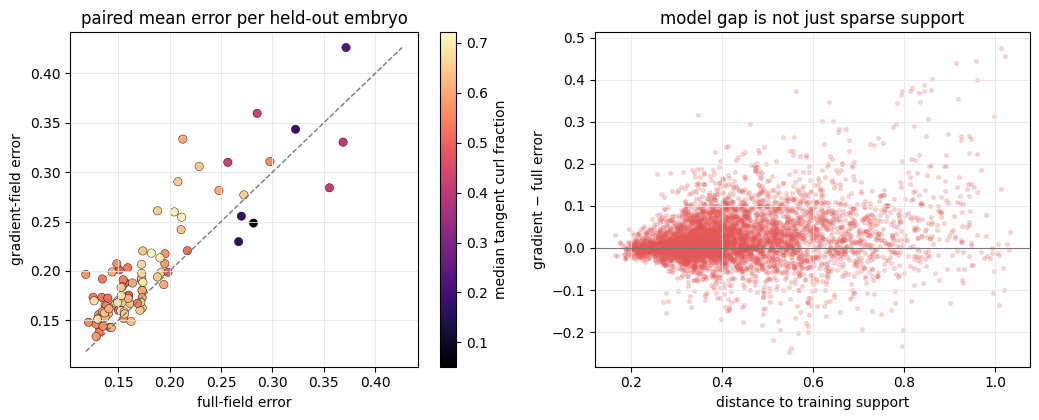

In [16]:
embryo_errors = dense_pred.groupby("embryo_id").agg(
    full_error=("full_error", "mean"),
    gradient_error=("gradient_error", "mean"),
    curl_fraction=("curl_fraction", "median"),
    support_distance=("support_distance", "median"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
lo = min(embryo_errors["full_error"].min(), embryo_errors["gradient_error"].min())
hi = max(embryo_errors["full_error"].max(), embryo_errors["gradient_error"].max())
axes[0].plot([lo, hi], [lo, hi], "--", color="#777777", lw=1)
sc = axes[0].scatter(
    embryo_errors["full_error"], embryo_errors["gradient_error"],
    c=embryo_errors["curl_fraction"], cmap="magma", edgecolor="black", linewidth=0.3,
)
axes[0].set_xlabel("full-field error")
axes[0].set_ylabel("gradient-field error")
axes[0].set_title("paired mean error per held-out embryo")
fig.colorbar(sc, ax=axes[0], label="median tangent curl fraction")

axes[1].scatter(
    dense_pred["support_distance"], dense_pred["gradient_excess_error"],
    s=7, alpha=0.2, color="#e45756",
)
axes[1].axhline(0, color="#777777", lw=0.8)
axes[1].set_xlabel("distance to training support")
axes[1].set_ylabel("gradient − full error")
axes[1].set_title("model gap is not just sparse support")
fig.tight_layout()
save_figure(fig, "07_paired_embryo_and_support_errors")
plt.show()

## 7. Sensitivity to trajectory smoothing

A real rotational signal should not disappear under a small change to the derivative smoothing
window. Conversely, strong variation here would say that the apparent curl is dominated by
differentiation noise. We repeat the entire held-out comparison at 5, 7, and 11 frames.

In [17]:
sensitivity_rows = []
sensitivity_predictions: dict[int, pd.DataFrame] = {SG_WINDOW: primary_predictions}

if RUN_SMOOTHING_SENSITIVITY:
    for window in SMOOTHING_WINDOWS:
        print(f"\n=== smoothing window {window} frames ===")
        if window == SG_WINDOW:
            predictions = primary_predictions
        else:
            table, _ = prepare_velocity_table(ref, window)
            predictions, _ = run_group_cv(table, verbose=False)
            sensitivity_predictions[window] = predictions
        summary, extras = score_predictions(predictions)
        row = {"window": window, **extras}
        for _, metric_row in summary.iterrows():
            kind = metric_row["model"]
            row[f"{kind}_velocity_r2"] = metric_row["velocity_r2"]
            row[f"{kind}_median_cosine"] = metric_row["median_cosine"]
            row[f"{kind}_one_step_skill"] = metric_row["one_step_skill_vs_persistence"]
        sensitivity_rows.append(row)

sensitivity = pd.DataFrame(sensitivity_rows).sort_values("window")
display(sensitivity.round(4))


=== smoothing window 5 frames ===

=== smoothing window 7 frames ===

=== smoothing window 11 frames ===


,window,predictable_drift_captured,gradient_excess_sse_vs_full,dense_fraction,median_tangent_dim,median_full_curl_fraction,unconstrained_velocity_r2,unconstrained_median_cosine,unconstrained_one_step_skill,gradient_velocity_r2,gradient_median_cosine,gradient_one_step_skill
0,5,0.9163,0.0615,0.8985,4.0,0.5946,0.7356,0.9316,0.6083,0.6741,0.9155,0.5617
1,7,0.9299,0.0566,0.8966,4.0,0.5975,0.8077,0.9553,0.6945,0.7511,0.9488,0.6494
2,11,0.9550,0.0398,0.9039,4.0,0.6475,0.8852,0.9751,0.7961,0.8454,0.9722,0.7619


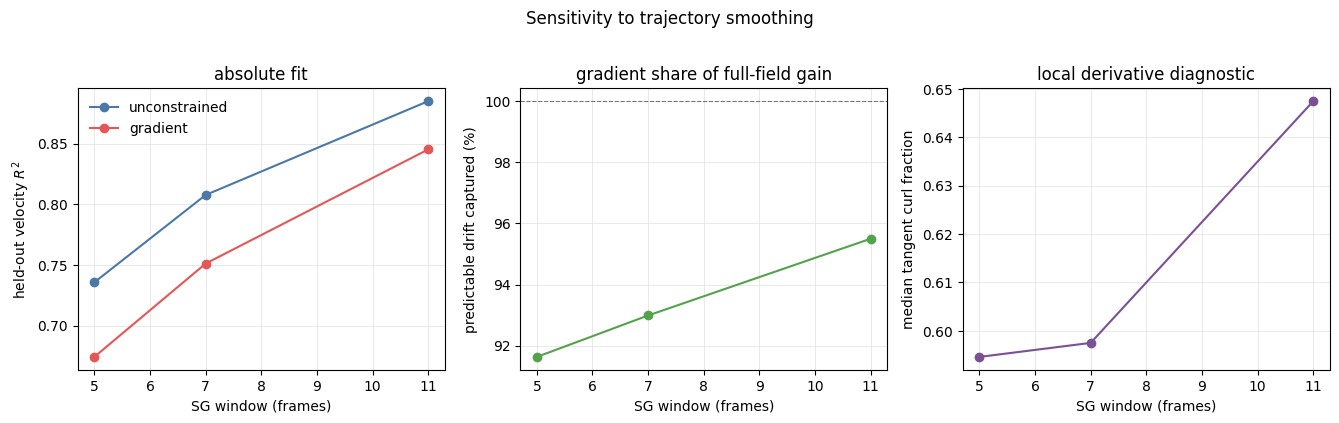

In [18]:
if len(sensitivity):
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.1))
    for kind in ("unconstrained", "gradient"):
        axes[0].plot(
            sensitivity["window"], sensitivity[f"{kind}_velocity_r2"], "o-",
            color=colors[kind], label=kind,
        )
    axes[0].set_xlabel("SG window (frames)")
    axes[0].set_ylabel("held-out velocity $R^2$")
    axes[0].legend(frameon=False)
    axes[0].set_title("absolute fit")

    axes[1].plot(
        sensitivity["window"], 100 * sensitivity["predictable_drift_captured"],
        "o-", color="#54a24b",
    )
    axes[1].axhline(100, color="#777777", ls="--", lw=0.8)
    axes[1].set_xlabel("SG window (frames)")
    axes[1].set_ylabel("predictable drift captured (%)")
    axes[1].set_title("gradient share of full-field gain")

    axes[2].plot(
        sensitivity["window"], sensitivity["median_full_curl_fraction"],
        "o-", color="#7a5195",
    )
    axes[2].set_xlabel("SG window (frames)")
    axes[2].set_ylabel("median tangent curl fraction")
    axes[2].set_title("local derivative diagnostic")
    fig.suptitle("Sensitivity to trajectory smoothing", y=1.02)
    fig.tight_layout()
    save_figure(fig, "08_smoothing_sensitivity")
    plt.show()

## 8. First-pass verdict

The code cell below states the conclusion numerically rather than hard-coding values into prose.
A gradient-only field is a fair exploratory approximation when it explains most held-out drift and
captures nearly all of the improvement achieved by the unconstrained field. A stable performance gap
plus non-negligible antisymmetric Jacobian indicates that a purely potential description is useful but
incomplete.

In [19]:
summary_path = FIG_DIR / "primary_metrics.csv"
sensitivity_path = FIG_DIR / "smoothing_sensitivity.csv"
primary_summary.assign(**primary_extras).to_csv(summary_path, index=False)
sensitivity.to_csv(sensitivity_path, index=False)

full_r2 = float(primary_summary.loc[primary_summary["model"].eq("unconstrained"), "velocity_r2"].iloc[0])
grad_r2 = float(primary_summary.loc[primary_summary["model"].eq("gradient"), "velocity_r2"].iloc[0])
full_cos = float(primary_summary.loc[primary_summary["model"].eq("unconstrained"), "median_cosine"].iloc[0])
grad_cos = float(primary_summary.loc[primary_summary["model"].eq("gradient"), "median_cosine"].iloc[0])
curl_med = float(primary_extras["median_full_curl_fraction"])

print("FIRST-PASS VERDICT")
print("------------------")
print(f"Dense-support evaluation retained {primary_extras['dense_fraction']:.1%} of held-out points.")
print(f"Unconstrained field: velocity R²={full_r2:.3f}, median cosine={full_cos:.3f}.")
print(f"Gradient-only field: velocity R²={grad_r2:.3f}, median cosine={grad_cos:.3f}.")
print(
    f"The gradient field captured {100 * capture:.1f}% "
    f"(95% embryo-bootstrap CI {100 * capture_ci[0]:.1f}–{100 * capture_ci[1]:.1f}%) "
    "of the predictable improvement achieved by the unconstrained field."
)
print(
    f"Median local tangent dimension: {primary_extras['median_tangent_dim']:.0f}; "
    f"median tangent antisymmetric-Jacobian fraction of the full field: {curl_med:.3f}."
)
print()
if capture >= 0.95:
    print("Interpretation: a gradient-only drift is a strong approximation on observed support;")
    print("the unconstrained field adds little reproducible structure in this first pass.")
elif capture >= 0.80:
    print("Interpretation: a gradient-only drift is a useful first-order approximation, but")
    print("the held-out gap indicates a modest, reproducible non-gradient component.")
else:
    print("Interpretation: the gradient-only restriction discards substantial predictable drift;")
    print("a purely potential field is not a sufficient representation on observed support.")

if len(sensitivity):
    spread = sensitivity["predictable_drift_captured"].max() - sensitivity["predictable_drift_captured"].min()
    print(f"Capture varies by {100 * spread:.1f} percentage points across smoothing windows.")
print("Saved metric tables:", summary_path, "and", sensitivity_path)

FIRST-PASS VERDICT
------------------
Dense-support evaluation retained 89.7% of held-out points.
Unconstrained field: velocity R²=0.808, median cosine=0.955.
Gradient-only field: velocity R²=0.751, median cosine=0.949.
The gradient field captured 93.0% (95% embryo-bootstrap CI 91.4–94.4%) of the predictable improvement achieved by the unconstrained field.
Median local tangent dimension: 4; median tangent antisymmetric-Jacobian fraction of the full field: 0.598.

Interpretation: a gradient-only drift is a useful first-order approximation, but
the held-out gap indicates a modest, reproducible non-gradient component.
Capture varies by 3.9 percentage points across smoothing windows.
Saved metric tables: /Users/nick/Projects/repositories/morphseq/results/nlammers/20260805/figures/drift_curl_free/primary_metrics.csv and /Users/nick/Projects/repositories/morphseq/results/nlammers/20260805/figures/drift_curl_free/smoothing_sensitivity.csv


### Scope of the conclusion

- This is a test of an autonomous conditional mean drift, not a stochastic diffusion model and not
  a density-weighted flux.
- Holding out whole embryos protects against memorizing individual trajectories.
- Results apply to the dense 14–44 hpf portion of the 20240812 WT reference manifold.
- Because local support has only about 4–5 effective dimensions, the notebook cannot rule out curl
  in unobserved directions of the nominal 10D space.
- A useful next iteration, if warranted, would repeat the comparison with a vector-valued curl-free
  kernel or a learned intrinsic coordinate chart. Agreement across model classes would make the
  conclusion considerably stronger.